# G1.1 数据快照与周频交易日历审计

**项目：** 基于 Alpha158 与机器学习的沪深300截面收益预测和指数增强研究  
**Notebook 类型：** 数据质量检查 + 教学式实验日志  
**读者：** 项目作者、面试官、复现实验的研究人员  
**研究阶段：** G1 的第一小步；本 Notebook 不计算因子、不训练模型

## tl;dr

下一单元格直接从冻结的质量 manifest 生成摘要。它回答三个问题：

1. 我们究竟绑定了哪一个数据快照？
2. 冻结快照是否通过基础质量门禁？
3. 周频信号—建仓—退出日期能否无歧义生成？

In [1]:
from pathlib import Path
import json
from IPython.display import Markdown, display

PROJECT_DIR = Path.cwd().resolve().parent
if PROJECT_DIR.name != "alpha158_project":
    raise RuntimeError(
        "请从 notebooks 目录执行本 Notebook；当前目录为 "
        f"{Path.cwd().resolve()}"
    )

DATA_LAKE = Path("/Users/mingyuxu/Desktop/因子挖掘/data_lake/tushare")
BUILD_MANIFEST = DATA_LAKE / "manifests/build-run-20260722T150836595381-c8eddf4e.json"
QUALITY_MANIFEST = DATA_LAKE / "manifests/data-quality-20260722T151048771524-9f29c218.json"
RESEARCH_CONFIG = PROJECT_DIR / "config/research_v1.json"
ARTIFACT_DIR = PROJECT_DIR / "artifacts/G1"

quality_manifest = json.loads(QUALITY_MANIFEST.read_text(encoding="utf-8"))
totals = quality_manifest["totals"]
display(Markdown(
    f'''
    **结论：基础快照状态为 `{quality_manifest["status"]}`。**

    - 快照：`{quality_manifest["snapshot_id"]}`
    - 覆盖：{totals["first_date"]} 至 {totals["last_date"]}
    - 行数：{totals["rows"]:,}
    - 股票：{totals["securities"]:,}
    - 交易日：{totals["dates"]:,}
    - 重复 `(股票, 日期)` 主键：{totals["duplicate_keys"]:,}
    - OHLC 关系错误：{totals["ohlc_violation_rows"]:,}
    - 缺失复权因子：{totals["missing_adj_factor"]:,}

    基础快照可进入 G1.1；历史成分有效区间仍未完成，所以 **尚不能进入模型训练**。
    '''
))


    **结论：基础快照状态为 `pass`。**

    - 快照：`tushare-silver-2015-01-05-2026-07-16-86b4445468cf2907`
    - 覆盖：2015-01-05 至 2026-07-16
    - 行数：11,168,836
    - 股票：5,456
    - 交易日：2,802
    - 重复 `(股票, 日期)` 主键：0
    - OHLC 关系错误：0
    - 缺失复权因子：0

    基础快照可进入 G1.1；历史成分有效区间仍未完成，所以 **尚不能进入模型训练**。
    

## Context & Methods

### 研究目标

本阶段不是寻找收益，而是证明数据的“时间、粒度、版本”可信。对于截面量化研究，数据质量错误往往会伪造出漂亮的 IC：

- 同一月份读取多个构建版本，会造成重复样本；
- 用当前沪深300成分回填历史，会造成幸存者偏差；
- 把月末权重快照当作调样生效日，会错配股票池；
- 用信号日收盘生成特征后仍按同日收盘成交，会造成前视偏差。

### Key Assumptions

- 时区和交易日定义：Asia/Shanghai，以上交所交易日历为准。
- 信号日：每个自然周最后一个开市日收盘。
- 建仓日：信号日后的第一个开市日开盘。
- 退出日：下一周组合的建仓日开盘。
- 正式信号日期：2015-01-01 至 2025-12-31。
- 为完成 2025 年末标签，允许读取 2026 年初的退出价格。
- 本 Notebook 只查看权重快照，不在此处推断成分生效区间。

## Data

### 1. 加载冻结配置与数据谱系

In [2]:
import platform
import sys

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "Hiragino Sans GB", "STHeiti"]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

research_config = json.loads(RESEARCH_CONFIG.read_text(encoding="utf-8"))
build_manifest = json.loads(BUILD_MANIFEST.read_text(encoding="utf-8"))

assert research_config["data"]["formal_source"]["snapshot_id"] == quality_manifest["snapshot_id"]
assert quality_manifest["status"] == "pass"
assert not quality_manifest["hard_failures"]

provenance = pd.DataFrame(
    [
        ("研究配置", str(RESEARCH_CONFIG)),
        ("构建 manifest", str(BUILD_MANIFEST)),
        ("质量 manifest", str(QUALITY_MANIFEST)),
        ("快照 ID", quality_manifest["snapshot_id"]),
        ("Python", sys.version.split()[0]),
        ("DuckDB", duckdb.__version__),
        ("平台", platform.platform()),
    ],
    columns=["项目", "值"],
)
provenance

,项目,值
0,研究配置,/Users/mingyuxu/Desktop/因子挖掘/factor-mining-exp...
1,构建 manifest,/Users/mingyuxu/Desktop/因子挖掘/data_lake/tushare...
2,质量 manifest,/Users/mingyuxu/Desktop/因子挖掘/data_lake/tushare...
3,快照 ID,tushare-silver-2015-01-05-2026-07-16-86b444546...
4,Python,3.13.2
5,DuckDB,1.5.5
6,平台,macOS-15.6.1-arm64-arm-64bit-Mach-O


### 2. 验证版本选择

`silver/equity_daily` 目录中保留了多轮构建产物。正式研究只能读取冻结 build manifest 中列出的文件，不能对整个目录使用 `*.parquet` 通配符。

In [3]:
silver_paths = [Path(item["path"]) for item in build_manifest["silver"]]
missing_silver_files = [str(path) for path in silver_paths if not path.is_file()]
all_silver_files = list((DATA_LAKE / "silver/equity_daily").rglob("*.parquet"))

version_audit = pd.DataFrame(
    [
        ("冻结 manifest 选中文件", len(silver_paths)),
        ("目录中全部历史版本文件", len(all_silver_files)),
        ("冻结文件缺失", len(missing_silver_files)),
        ("冻结月份数", len({item["period"] for item in build_manifest["silver"]})),
    ],
    columns=["检查", "数量"],
)
assert len(missing_silver_files) == 0
assert len(silver_paths) == len({item["period"] for item in build_manifest["silver"]})
version_audit

,检查,数量
0,冻结 manifest 选中文件,139
1,目录中全部历史版本文件,376
2,冻结文件缺失,0
3,冻结月份数,139


### 3. 独立复算核心主键和覆盖范围

In [4]:
connection = duckdb.connect(database=":memory:")
connection.execute("PRAGMA threads=4")
connection.execute("PRAGMA memory_limit='4GB'")
connection.read_parquet([str(path) for path in silver_paths]).create_view("equity_daily_frozen")

frozen_profile = connection.execute(
    '''
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT (ts_code, trade_date)) AS distinct_keys,
        COUNT(*) - COUNT(DISTINCT (ts_code, trade_date)) AS duplicate_keys,
        COUNT(DISTINCT ts_code) AS securities,
        COUNT(DISTINCT trade_date) AS dates,
        MIN(trade_date)::DATE AS first_date,
        MAX(trade_date)::DATE AS last_date,
        COUNT_IF(open IS NULL) AS missing_open,
        COUNT_IF(adj_factor IS NULL) AS missing_adj_factor,
        COUNT_IF(total_mv_cny IS NULL) AS missing_total_mv
    FROM equity_daily_frozen
    '''
).fetchdf()

observed = frozen_profile.iloc[0]
assert int(observed["rows"]) == totals["rows"]
assert int(observed["duplicate_keys"]) == totals["duplicate_keys"]
assert pd.Timestamp(observed["first_date"]).date().isoformat() == totals["first_date"]
assert pd.Timestamp(observed["last_date"]).date().isoformat() == totals["last_date"]
frozen_profile

,rows,distinct_keys,duplicate_keys,securities,dates,first_date,last_date,missing_open,missing_adj_factor,missing_total_mv
0,11168836,11168836,0,5456,2802,2015-01-05,2026-07-16,0.0,0.0,2916.0


### 4. 查看正式行情字段

In [5]:
schema = connection.execute(
    "DESCRIBE SELECT * FROM equity_daily_frozen"
).fetchdf()[["column_name", "column_type"]]
schema

,column_name,column_type
0,ts_code,VARCHAR
1,trade_date,TIMESTAMP_NS
2,open,DOUBLE
3,high,DOUBLE
4,low,DOUBLE
5,close,DOUBLE
6,pre_close,DOUBLE
7,change,DOUBLE
8,pct_chg,DOUBLE
9,vol,DOUBLE


## Results

### 5. 月度规模、缺失率与行业覆盖

行数随上市公司数量增长是正常现象；真正需要警惕的是某个月份突然断层、关键字段缺失率跳升，或行业覆盖异常下降。

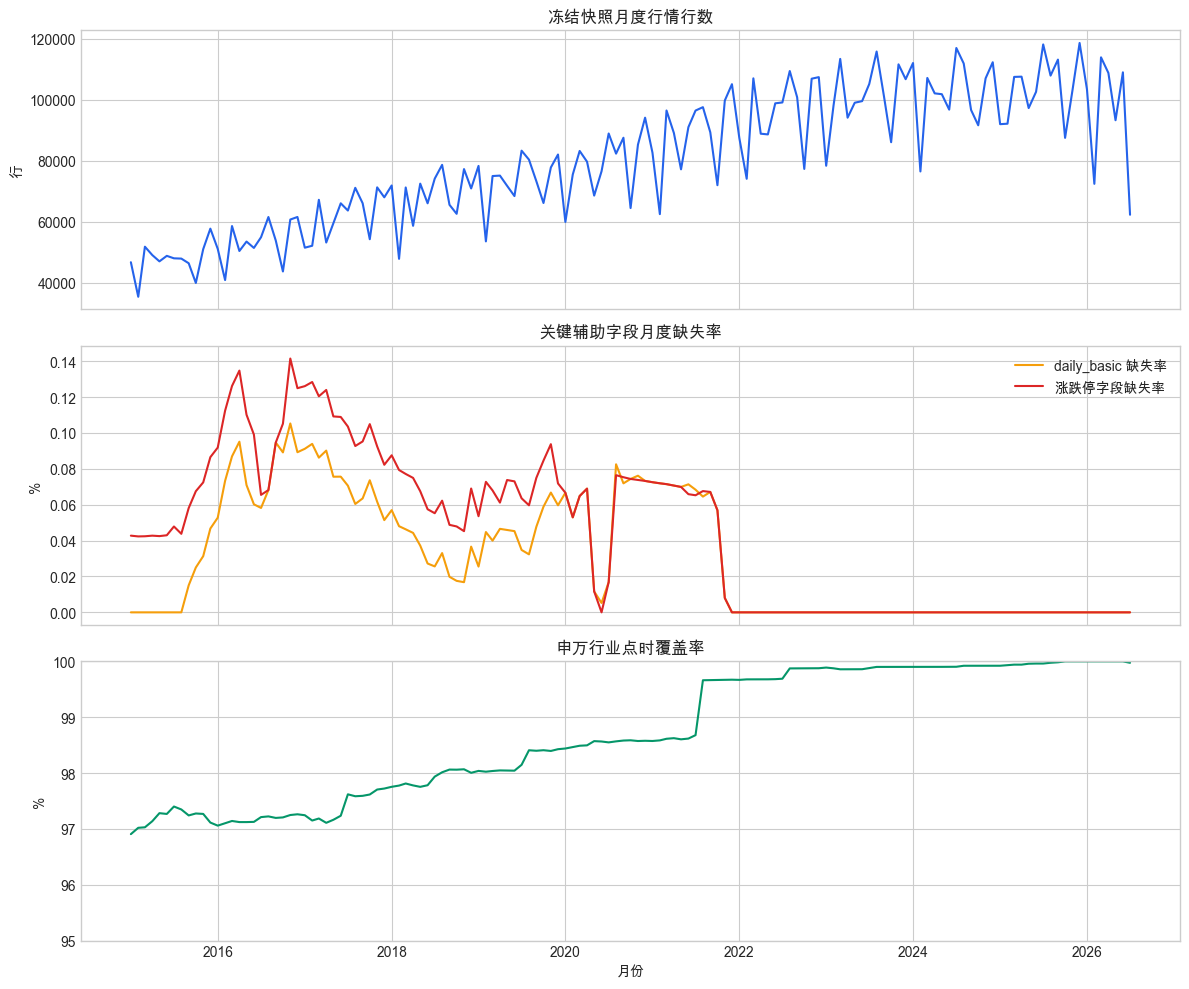

In [6]:
monthly_quality = pd.DataFrame(quality_manifest["monthly"])
monthly_quality["period_date"] = pd.to_datetime(monthly_quality["period"])
monthly_quality["missing_daily_basic_rate"] = (
    monthly_quality["missing_daily_basic"] / monthly_quality["rows"]
)
monthly_quality["missing_limit_rate"] = (
    monthly_quality["missing_limit"] / monthly_quality["rows"]
)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes[0].plot(monthly_quality["period_date"], monthly_quality["rows"], color="#2563EB")
axes[0].set_title("冻结快照月度行情行数")
axes[0].set_ylabel("行")

axes[1].plot(
    monthly_quality["period_date"],
    monthly_quality["missing_daily_basic_rate"] * 100,
    label="daily_basic 缺失率",
    color="#F59E0B",
)
axes[1].plot(
    monthly_quality["period_date"],
    monthly_quality["missing_limit_rate"] * 100,
    label="涨跌停字段缺失率",
    color="#DC2626",
)
axes[1].set_title("关键辅助字段月度缺失率")
axes[1].set_ylabel("%")
axes[1].legend()

axes[2].plot(
    monthly_quality["period_date"],
    monthly_quality["industry_coverage"] * 100,
    color="#059669",
)
axes[2].set_title("申万行业点时覆盖率")
axes[2].set_ylabel("%")
axes[2].set_xlabel("月份")
axes[2].set_ylim(95, 100)

fig.tight_layout()
plt.show()

In [7]:
monthly_flags = monthly_quality.loc[
    (monthly_quality["duplicate_keys"] > 0)
    | (monthly_quality["missing_adj_factor"] > 0)
    | (monthly_quality["industry_coverage"] < 0.97),
    [
        "period",
        "rows",
        "duplicate_keys",
        "missing_adj_factor",
        "missing_daily_basic_rate",
        "missing_limit_rate",
        "industry_coverage",
    ],
].copy()
monthly_flags

,period,rows,duplicate_keys,missing_adj_factor,missing_daily_basic_rate,missing_limit_rate,industry_coverage
0,2015-01,46772,0,0,0.0,0.000428,0.969063


### 6. 生成周频信号—建仓—退出日历

注意：这里使用交易所开市日，而不是简单地取每个星期五。节假日周的信号日可能是周三或周四。

In [8]:
trade_calendar_path = Path(
    build_manifest["reference"]["files"]["trade_calendar"]["path"]
)
trade_calendar = connection.execute(
    '''
    SELECT
        STRPTIME(cal_date, '%Y%m%d')::DATE AS trade_date
    FROM read_parquet(?)
    WHERE exchange = 'SSE' AND is_open = 1
    ORDER BY trade_date
    ''',
    [str(trade_calendar_path)],
).fetchdf()
trade_calendar["trade_date"] = pd.to_datetime(trade_calendar["trade_date"])

open_dates = pd.DatetimeIndex(trade_calendar["trade_date"].drop_duplicates().sort_values())
calendar_frame = pd.DataFrame({"trade_date": open_dates})
iso = calendar_frame["trade_date"].dt.isocalendar()
calendar_frame["iso_year"] = iso["year"].astype(int)
calendar_frame["iso_week"] = iso["week"].astype(int)

weekly_all = (
    calendar_frame.groupby(["iso_year", "iso_week"], as_index=False)
    .agg(
        signal_date=("trade_date", "max"),
        trading_days_in_week=("trade_date", "size"),
    )
    .sort_values("signal_date")
    .reset_index(drop=True)
)

positions = open_dates.searchsorted(
    pd.DatetimeIndex(weekly_all["signal_date"]), side="right"
)
weekly_all["entry_date"] = [
    open_dates[position] if position < len(open_dates) else pd.NaT
    for position in positions
]
weekly_all["exit_date"] = weekly_all["entry_date"].shift(-1)

sample_start = pd.Timestamp(research_config["data"]["formal_sample"]["start"])
sample_end = pd.Timestamp(research_config["data"]["formal_sample"]["end"])
weekly_calendar = weekly_all.loc[
    weekly_all["signal_date"].between(sample_start, sample_end)
].copy()

weekly_calendar["holding_calendar_days"] = (
    weekly_calendar["exit_date"] - weekly_calendar["entry_date"]
).dt.days
weekly_calendar["signal_weekday"] = weekly_calendar["signal_date"].dt.day_name()

assert weekly_calendar["signal_date"].is_unique
assert weekly_calendar["entry_date"].notna().all()
assert weekly_calendar["exit_date"].notna().all()
assert (weekly_calendar["signal_date"] < weekly_calendar["entry_date"]).all()
assert (weekly_calendar["entry_date"] < weekly_calendar["exit_date"]).all()

weekly_calendar.head(10)

,iso_year,iso_week,signal_date,trading_days_in_week,entry_date,exit_date,holding_calendar_days,signal_weekday
0,2015,2,2015-01-09,5,2015-01-12,2015-01-19,7,Friday
1,2015,3,2015-01-16,5,2015-01-19,2015-01-26,7,Friday
2,2015,4,2015-01-23,5,2015-01-26,2015-02-02,7,Friday
3,2015,5,2015-01-30,5,2015-02-02,2015-02-09,7,Friday
4,2015,6,2015-02-06,5,2015-02-09,2015-02-16,7,Friday
5,2015,7,2015-02-13,5,2015-02-16,2015-02-25,9,Friday
6,2015,8,2015-02-17,2,2015-02-25,2015-03-02,5,Tuesday
7,2015,9,2015-02-27,3,2015-03-02,2015-03-09,7,Friday
8,2015,10,2015-03-06,5,2015-03-09,2015-03-16,7,Friday
9,2015,11,2015-03-13,5,2015-03-16,2015-03-23,7,Friday


In [9]:
calendar_summary = pd.DataFrame(
    [
        ("正式周度样本数", len(weekly_calendar)),
        ("首个信号日", weekly_calendar["signal_date"].min().date()),
        ("最后信号日", weekly_calendar["signal_date"].max().date()),
        ("最后建仓日", weekly_calendar["entry_date"].max().date()),
        ("最后退出日", weekly_calendar["exit_date"].max().date()),
        ("非周五信号数", int((weekly_calendar["signal_weekday"] != "Friday").sum())),
        ("最短持有日历天", int(weekly_calendar["holding_calendar_days"].min())),
        ("最长持有日历天", int(weekly_calendar["holding_calendar_days"].max())),
    ],
    columns=["检查", "结果"],
)
calendar_summary

,检查,结果
0,正式周度样本数,563
1,首个信号日,2015-01-09
2,最后信号日,2025-12-31
3,最后建仓日,2026-01-05
4,最后退出日,2026-01-12
5,非周五信号数,34
6,最短持有日历天,3
7,最长持有日历天,14


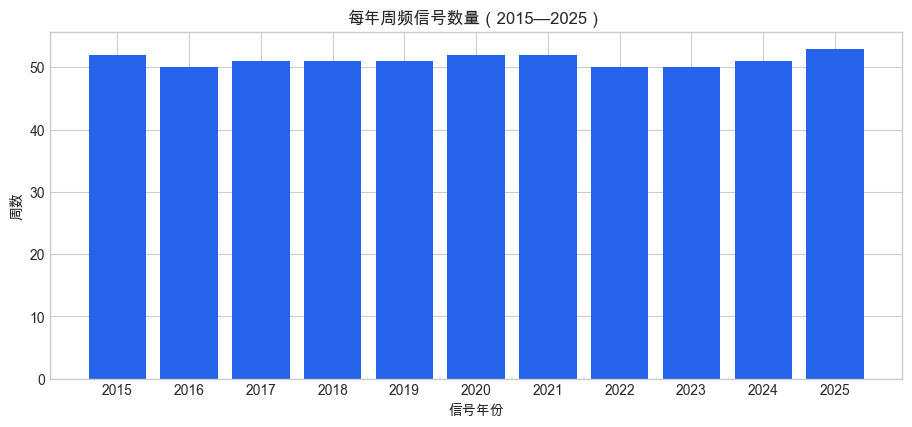

,year,signal_weeks,non_friday_signals
0,2015,52,5
1,2016,50,2
2,2017,51,1
3,2018,51,2
4,2019,51,5
5,2020,52,5
6,2021,52,2
7,2022,50,1
8,2023,50,2
9,2024,51,4


In [10]:
signals_by_year = (
    weekly_calendar.assign(year=weekly_calendar["signal_date"].dt.year)
    .groupby("year", as_index=False)
    .agg(
        signal_weeks=("signal_date", "size"),
        non_friday_signals=("signal_weekday", lambda values: (values != "Friday").sum()),
    )
)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(signals_by_year["year"], signals_by_year["signal_weeks"], color="#2563EB")
ax.set_title("每年周频信号数量（2015—2025）")
ax.set_xlabel("信号年份")
ax.set_ylabel("周数")
ax.set_xticks(signals_by_year["year"])
plt.show()
signals_by_year

### 7. 审计沪深300月度权重快照

这里先回答“快照本身是否完整、哪些月份发生了成员变化”。  
**暂时不把快照变化日期等同于指数调整生效日期。**

In [11]:
membership_snapshot_path = Path(
    build_manifest["reference"]["files"]["index_weight_000300_SH"]["path"]
)
membership = connection.execute(
    '''
    SELECT
        index_code,
        con_code,
        STRPTIME(trade_date, '%Y%m%d')::DATE AS snapshot_date,
        weight
    FROM read_parquet(?)
    ORDER BY snapshot_date, con_code
    ''',
    [str(membership_snapshot_path)],
).fetchdf()
membership["snapshot_date"] = pd.to_datetime(membership["snapshot_date"])

snapshot_counts = (
    membership.groupby("snapshot_date", as_index=False)
    .agg(
        constituents=("con_code", "nunique"),
        rows=("con_code", "size"),
        weight_sum=("weight", "sum"),
    )
)

assert not membership.duplicated(["snapshot_date", "con_code"]).any()
snapshot_counts.describe(include="all")

,snapshot_date,constituents,rows,weight_sum
count,138,138.0,138.0,138.000000
mean,2020-10-14 04:31:18.260869,300.0,300.0,100.000094
min,2015-01-30 00:00:00,300.0,300.0,99.930000
25%,2017-12-07 06:00:00,300.0,300.0,99.996000
50%,2020-10-15 00:00:00,300.0,300.0,100.000000
75%,2023-08-23 06:00:00,300.0,300.0,100.004000
max,2026-06-30 00:00:00,300.0,300.0,100.060000
std,NaN,0.0,0.0,0.010136


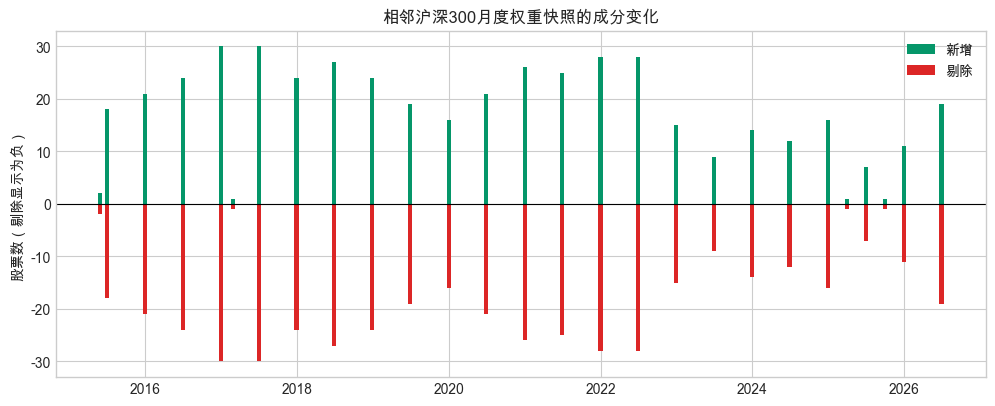

,previous_snapshot,snapshot_date,added_count,removed_count,added,removed
3,2015-04-30,2015-05-29,2,2,"000738.SZ, 300003.SZ","600832.SH, 601299.SH"
4,2015-05-29,2015-06-30,18,18,"000046.SZ, 000539.SZ, 000712.SZ, 002736.SZ, 30...","000401.SZ, 000536.SZ, 000869.SZ, 002400.SZ, 00..."
10,2015-11-30,2015-12-31,21,21,"000415.SZ, 000540.SZ, 001979.SZ, 002195.SZ, 00...","000024.SZ, 000839.SZ, 000878.SZ, 000960.SZ, 00..."
16,2016-05-31,2016-06-30,24,24,"000839.SZ, 000977.SZ, 002027.SZ, 002152.SZ, 00...","000400.SZ, 000539.SZ, 000581.SZ, 000598.SZ, 00..."
22,2016-11-30,2016-12-30,30,30,"000008.SZ, 000555.SZ, 000627.SZ, 000671.SZ, 00...","000046.SZ, 000729.SZ, 000825.SZ, 000883.SZ, 00..."
24,2017-01-26,2017-02-28,1,1,600549.SH,600005.SH
28,2017-05-31,2017-06-30,30,30,"000959.SZ, 000961.SZ, 002044.SZ, 002352.SZ, 00...","000027.SZ, 000039.SZ, 000061.SZ, 000712.SZ, 00..."
34,2017-11-30,2017-12-29,24,24,"000723.SZ, 000898.SZ, 002294.SZ, 002460.SZ, 00...","000009.SZ, 000156.SZ, 000555.SZ, 000718.SZ, 00..."
40,2018-05-31,2018-06-29,27,27,"000786.SZ, 001965.SZ, 002050.SZ, 002085.SZ, 00...","000008.SZ, 000686.SZ, 000738.SZ, 000750.SZ, 00..."
46,2018-11-30,2018-12-28,24,24,"000408.SZ, 000553.SZ, 000661.SZ, 000703.SZ, 00...","000060.SZ, 000540.SZ, 000559.SZ, 000623.SZ, 00..."


In [12]:
member_sets = (
    membership.groupby("snapshot_date")["con_code"]
    .apply(set)
    .sort_index()
)
change_records = []
previous_date = None
previous_members = None
for snapshot_date, current_members in member_sets.items():
    if previous_members is not None:
        added = sorted(current_members - previous_members)
        removed = sorted(previous_members - current_members)
        change_records.append(
            {
                "previous_snapshot": previous_date,
                "snapshot_date": snapshot_date,
                "added_count": len(added),
                "removed_count": len(removed),
                "added": ", ".join(added),
                "removed": ", ".join(removed),
            }
        )
    previous_date = snapshot_date
    previous_members = current_members

snapshot_changes = pd.DataFrame(change_records)
changed_snapshots = snapshot_changes.loc[
    (snapshot_changes["added_count"] > 0)
    | (snapshot_changes["removed_count"] > 0)
].copy()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(
    changed_snapshots["snapshot_date"],
    changed_snapshots["added_count"],
    width=20,
    label="新增",
    color="#059669",
)
ax.bar(
    changed_snapshots["snapshot_date"],
    -changed_snapshots["removed_count"],
    width=20,
    label="剔除",
    color="#DC2626",
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("相邻沪深300月度权重快照的成分变化")
ax.set_ylabel("股票数（剔除显示为负）")
ax.legend()
plt.show()

changed_snapshots[
    [
        "previous_snapshot",
        "snapshot_date",
        "added_count",
        "removed_count",
        "added",
        "removed",
    ]
]

### 8. 保存可复现产物

In [13]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

weekly_calendar_output = ARTIFACT_DIR / "weekly_calendar_g1_1.parquet"
snapshot_changes_output = ARTIFACT_DIR / "membership_snapshot_changes_g1_1.parquet"
audit_output = ARTIFACT_DIR / "data_calendar_audit_g1_1.json"

weekly_calendar.to_parquet(weekly_calendar_output, index=False)
snapshot_changes.to_parquet(snapshot_changes_output, index=False)

audit_payload = {
    "stage": "G1.1",
    "status": "pass",
    "snapshot_id": quality_manifest["snapshot_id"],
    "build_manifest": str(BUILD_MANIFEST),
    "quality_manifest": str(QUALITY_MANIFEST),
    "selected_silver_files": len(silver_paths),
    "all_historical_silver_files": len(all_silver_files),
    "rows": int(observed["rows"]),
    "duplicate_keys": int(observed["duplicate_keys"]),
    "first_date": pd.Timestamp(observed["first_date"]).date().isoformat(),
    "last_date": pd.Timestamp(observed["last_date"]).date().isoformat(),
    "weekly_samples": len(weekly_calendar),
    "first_signal_date": weekly_calendar["signal_date"].min().date().isoformat(),
    "last_signal_date": weekly_calendar["signal_date"].max().date().isoformat(),
    "last_exit_date": weekly_calendar["exit_date"].max().date().isoformat(),
    "membership_snapshots": int(membership["snapshot_date"].nunique()),
    "membership_rows": len(membership),
    "membership_changed_snapshots": len(changed_snapshots),
    "unresolved_gate": "G1.2 point-in-time effective membership intervals",
    "outputs": {
        "weekly_calendar": str(weekly_calendar_output),
        "membership_snapshot_changes": str(snapshot_changes_output),
    },
}
audit_output.write_text(
    json.dumps(audit_payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
audit_payload

{'stage': 'G1.1',
 'status': 'pass',
 'snapshot_id': 'tushare-silver-2015-01-05-2026-07-16-86b4445468cf2907',
 'build_manifest': '/Users/mingyuxu/Desktop/因子挖掘/data_lake/tushare/manifests/build-run-20260722T150836595381-c8eddf4e.json',
 'quality_manifest': '/Users/mingyuxu/Desktop/因子挖掘/data_lake/tushare/manifests/data-quality-20260722T151048771524-9f29c218.json',
 'selected_silver_files': 139,
 'all_historical_silver_files': 376,
 'rows': 11168836,
 'duplicate_keys': 0,
 'first_date': '2015-01-05',
 'last_date': '2026-07-16',
 'weekly_samples': 563,
 'first_signal_date': '2015-01-09',
 'last_signal_date': '2025-12-31',
 'last_exit_date': '2026-01-12',
 'membership_snapshots': 138,
 'membership_rows': 41400,
 'membership_changed_snapshots': 27,
 'unresolved_gate': 'G1.2 point-in-time effective membership intervals',
 'outputs': {'weekly_calendar': '/Users/mingyuxu/Desktop/因子挖掘/factor-mining-experiment-master/local_research/alpha158_project/artifacts/G1/weekly_calendar_g1_1.parquet',
  'm

## Takeaways

In [14]:
display(Markdown(
    f'''
    ### 本步结论

    1. 冻结快照与质量 manifest 一致，共 **{int(observed["rows"]):,}** 行，
       重复主键为 **{int(observed["duplicate_keys"]):,}**。
    2. 数据目录实际保留 **{len(all_silver_files)}** 个历史版本文件，
       正式 manifest 只选择 **{len(silver_paths)}** 个；因此禁止全目录通配读取。
    3. 2015—2025 共生成 **{len(weekly_calendar)}** 个周频信号，
       最后一个信号的退出日为 **{weekly_calendar["exit_date"].max().date()}**。
    4. 权重数据共有 **{membership["snapshot_date"].nunique()}** 个快照、
       **{len(membership):,}** 行；相邻快照中有 **{len(changed_snapshots)}** 次成员变化。
    5. **G1 尚未整体通过。** 下一步必须将月度快照变化映射成官方生效日期，
       并核实临时调样事件，之后才能构建 point-in-time 股票池。

    ### 面试表达

    > 我没有直接把数据目录里的 Parquet 全部读入，因为数据湖保留了多轮构建版本。
    > 我绑定冻结 manifest 并独立复算主键和日期覆盖，避免版本重复。
    > 周频样本完全基于交易所日历生成，信号在周末最后一个交易日收盘形成，
    > 下一交易日开盘成交；月度指数权重只作为成员快照，不能直接当作调样生效日。
    '''
))


    ### 本步结论

    1. 冻结快照与质量 manifest 一致，共 **11,168,836** 行，
       重复主键为 **0**。
    2. 数据目录实际保留 **376** 个历史版本文件，
       正式 manifest 只选择 **139** 个；因此禁止全目录通配读取。
    3. 2015—2025 共生成 **563** 个周频信号，
       最后一个信号的退出日为 **2026-01-12**。
    4. 权重数据共有 **138** 个快照、
       **41,400** 行；相邻快照中有 **27** 次成员变化。
    5. **G1 尚未整体通过。** 下一步必须将月度快照变化映射成官方生效日期，
       并核实临时调样事件，之后才能构建 point-in-time 股票池。

    ### 面试表达

    > 我没有直接把数据目录里的 Parquet 全部读入，因为数据湖保留了多轮构建版本。
    > 我绑定冻结 manifest 并独立复算主键和日期覆盖，避免版本重复。
    > 周频样本完全基于交易所日历生成，信号在周末最后一个交易日收盘形成，
    > 下一交易日开盘成交；月度指数权重只作为成员快照，不能直接当作调样生效日。
    